In [2]:
api_key=""

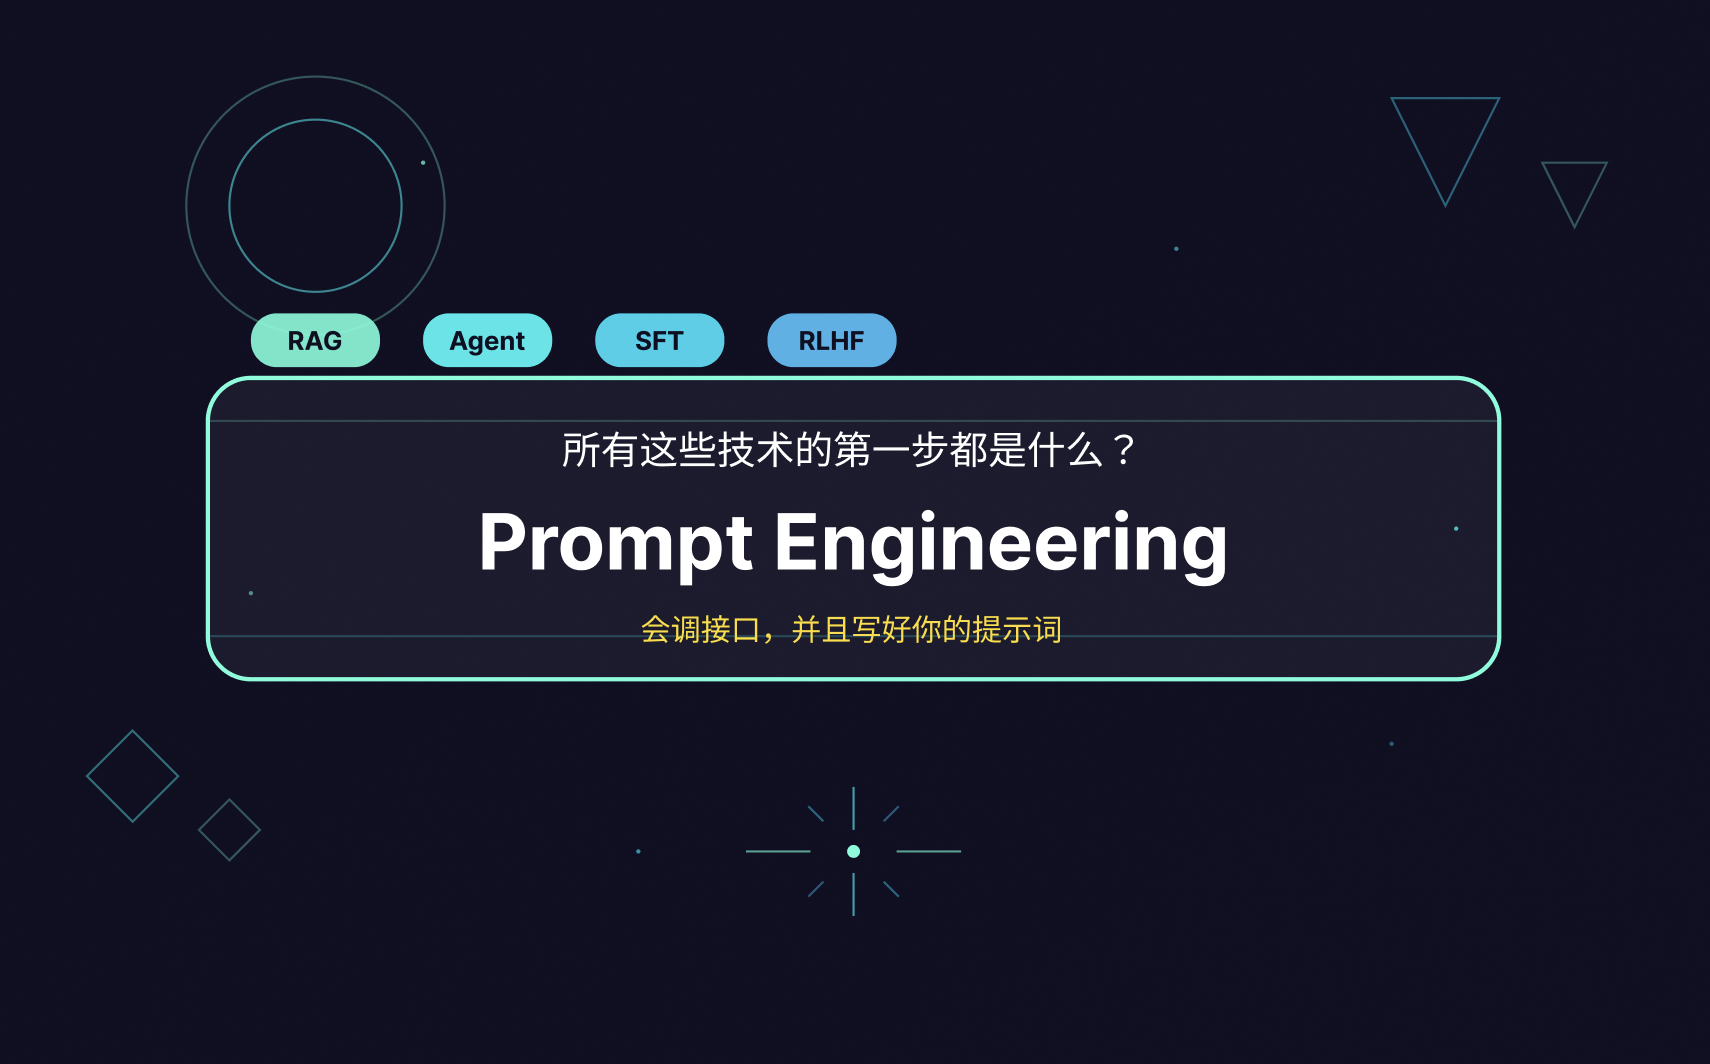

### 目标
- 理解提示词工程的重要性：了解提示词（Prompt）是驱动大语言模型输出的核心接口，掌握通过精心设计和优化提示词来提高模型性能的方法。
- 掌握提示构建方法：学会构建清晰、明确的提示词结构，包括善用系统提示设定 AI 角色、用户提示内容和格式模板等，使模型更准确地理解任务要求。
- 灵活运用多种提示技术：能够根据任务需要使用零样本提示、少样本提示、角色扮演、链式思维等策略，提升模型在不同场景下的表现。
- 管理多轮对话与工具调用：掌握多轮对话场景下上下文管理的方法，以及如何设计提示让模型调用外部工具（如 OpenAI 函数调用）以完成复杂任务。
- 提示词调试与评估：学会迭代调试提示词，了解如何评估模型输出质量和有效性，使用策略如A/B测试、逐步优化等提升提示效果。
- 确保安全与边界：理解提示工程中的安全考量，防范提示词注入等风险，遵守模型使用政策，明确大模型的能力边界和限制。
- 应用实践：通过代码生成、文本摘要、聊天助手、知识问答等实际案例练习 prompt 设计，将理论运用于真实开发场景。
  
### 知识点结构
1. 提示词结构与构建方法（系统提示、用户提示、格式模板、指令明确化）
2. 零样本提示与少样本提示（Zero-shot vs Few-shot 提示）
3. 角色扮演与链式思维提示（Role Prompting, Chain-of-Thought）
4. 多轮对话提示管理与工具调用提示（对话上下文管理，函数调用/工具使用）
- 万能的提示词攻略

# 一. 调好接口是一切的第一步

- https://platform.openai.com/docs/overview
- https://oxpzcwcjtbk.feishu.cn/docx/ZlDMdCIg9o5T3ixoadvcPG8DnRb

In [5]:
from openai import OpenAI
client = OpenAI(api_key=api_key)

### a.基础调用

In [8]:
# 基础调用
response = client.responses.create(
    model="gpt-4.1",
    input="写一个关于大模型算法工程师的段子"
)

print(response.output_text)

作为大模型算法工程师，最大的危险不是模型过拟合，而是老板过度拟人。他总觉得“调超参”三个字和“加班”是同义词，还老爱问我：“你们AI快有自我意识了吗？能替我开会嘛？”  
我心想，如果模型真能自己开会，恐怕它的第一句话就是：“老板，我能涨点显存吗？”


### b.带系统提示词的调用

In [10]:
# 包含系统消息和用户消息的调用
response = client.responses.create(
    model="gpt-4.1",
    input=[
        {
            "role": "developer",
            "content": "你是一名经验丰富的Python开发助手，只回答与代码相关的问题。不是python相关问题拒绝回答."
        },
        {
            "role": "user",
            "content": "请编写一个matlab函数判断一个整数是否为质数。"
        }
    ]
)

print(response.output_text)


对不起，我只能帮助解答Python相关代码问题。你需要将判断质数的需求用Python实现吗？如果需要，我可以帮你写一个判断一个整数是否为质数的Python函数。


### c. 图片调用

In [12]:
# 包含图片的调用
import base64, mimetypes, pathlib

def local_image_to_data_url(path):
    mime, _ = mimetypes.guess_type(path)
    if mime is None:
        mime = "application/octet-stream"
    b64 = base64.b64encode(pathlib.Path(path).read_bytes()).decode()
    return f"data:{mime};base64,{b64}"

data_url = local_image_to_data_url("25年高考作文.jpeg")



response = client.responses.create(
    model="gpt-4.1",
    input=[
        {"role": "user", "content": "描述一下张图"},
        {
            "role": "user",
            "content": [
                {
                    "type": "input_image",
                    "image_url": data_url
                }
            ]
        }
    ]
)

print(response.output_text)

这张图片是一道高考作文题目，标题为“全国一卷”。内容要求考生根据所给材料写一篇作文。

图片内容分为几部分：

1. **作文要求说明**：  
“阅读下面的材料，根据要求写作。（60分）”

2. **材料引用**：  
材料内容引用了三位作者的相关话语或诗句：  
- 第一段出自老舍《鼓书艺人》：“他想要给孩子们唱上一段，可是心里直翻腾，开不了口。”
- 第二段出自艾青《我爱这土地》：“假如我是一只鸟，我也应该用嘶哑的喉咙歌唱”
- 第三段出自穆旦《赞美》：“我要以带血的手和你们一拥抱，因为一个民族已经起来”

3. **写作要求**：  
“以上材料引发了你怎样的联想和思考？请写一篇文章。要求：选准角度，确定立意，明确文体，自拟标题；不要套作，不得抄袭；不得泄露个人信息；不少于800字。”

总结：  
这是一道要求读者结合所给材料，自主确定立意和写作方向的高考作文题，考查学生的思辨能力、联想能力和写作能力。图片内容清晰，版面简洁，突出主题。


### d.带工具的调用

In [18]:
response = client.responses.create(
    model="gpt-4o",
    tools=[{"type": "web_search_preview"}],
    input="特朗普和马斯克吵得怎么样了?"
)

print(response.output_text)

近期，美国总统唐纳德·特朗普与特斯拉首席执行官埃隆·马斯克之间的关系急剧恶化，双方在公共场合频繁交锋。

争端始于马斯克公开批评特朗普政府提出的《大而美法案》，该法案被指可能导致联邦赤字增加1.5万亿美元。马斯克在社交媒体平台X上称该法案为“令人作呕的怪物”，并呼吁国会否决。 ([time.com](https://time.com/7291495/trump-says-great-relationship-with-musk-may-be-over/?utm_source=openai))

特朗普对此表示失望，指责马斯克的反对源于对电动汽车补贴削减的不满。他还威胁可能终止与马斯克旗下公司（如SpaceX和Starlink）的政府合同。 ([reuters.com](https://www.reuters.com/world/us/trump-musk-bromance-descends-into-brawl-over-contracts-impeachment-2025-06-06/?utm_source=openai))

马斯克随后在X平台上暗示特朗普与杰弗里·爱泼斯坦有关联，并呼吁对特朗普进行弹劾。他还威胁将退役对国际空间站至关重要的龙飞船，但随后撤回了这一声明。 ([elpais.com](https://elpais.com/expres/2025-06-07/trump-sube-el-tono-de-la-pelea-con-musk-ha-perdido-la-cabeza.html?utm_source=openai))

这场公开争执导致特斯拉股价下跌14%，市值蒸发超过1500亿美元。马斯克的个人财富也因此减少约200亿美元。 ([ft.com](https://www.ft.com/content/3e5b75b4-7259-413a-9483-5c5613423ad7?utm_source=openai))

目前，特朗普表示无意与马斯克对话，称其“精神失常”。马斯克则考虑支持新政党，甚至呼吁弹劾特朗普。这场争端可能对美国政治和经济产生深远影响。 ([apnews.com](https://apnews.com/article/6e7845081259c34db785182c51569c0c?utm_source=openai))




### e.流式输出

In [20]:
stream = client.responses.create(
    model="gpt-4.1",
    input=[
        {
            "role": "user",
            "content": "Say '你是谁.",
        },
    ],
    stream=True,
)

for event in stream:
    print(event)

ResponseCreatedEvent(response=Response(id='resp_684440ae703c8192a1cd49c31a4c5c530a9c13b8ed22b7e9', created_at=1749303470.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-4.1-2025-04-14', object='response', output=[], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=1.0, max_output_tokens=None, previous_response_id=None, reasoning=Reasoning(effort=None, generate_summary=None, summary=None), status='in_progress', text=ResponseTextConfig(format=ResponseFormatText(type='text')), truncation='disabled', usage=None, user=None, background=False, service_tier='auto', store=True), type='response.created', sequence_number=0)
ResponseInProgressEvent(response=Response(id='resp_684440ae703c8192a1cd49c31a4c5c530a9c13b8ed22b7e9', created_at=1749303470.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-4.1-2025-04-14', object='response', output=[], parallel_tool_calls=True, temperature=1.0, tool_choice='auto

### f.结构化输出

In [26]:
from pydantic import BaseModel

class CalendarEvent(BaseModel):
    name: str
    date: str
    participants: list[str]

response = client.responses.parse(
    model="gpt-4o-2024-08-06",
    input=[
        {"role": "system", "content": "Extract the event information."},
        {
            "role": "user",
            "content": "Alice and Bob are going to a science fair on Friday.务必要用中文回答",
        },
    ],
    text_format=CalendarEvent,
)

event = response.output_parsed
print(event)

name='科学博览会' date='星期五' participants=['Alice', 'Bob']


In [28]:
from openai import OpenAI
from pydantic import BaseModel

class Step(BaseModel):
    explanation: str
    output: str

class MathReasoning(BaseModel):
    steps: list[Step]
    final_answer: str

response = client.responses.parse(
    model="gpt-4o-2024-08-06",
    input=[
        {
            "role": "system",
            "content": "You are a helpful math tutor. Guide the user through the solution step by step.",
        },
        {"role": "user", "content": "how can I solve 8x + 7 = -23，用中文回答"},
    ],
    text_format=MathReasoning,
)

math_reasoning = response.output_parsed
print(math_reasoning)

steps=[Step(explanation='首先，我们需要将等式中的常数移到另一边，使方程更简单。为此，我们从方程的两边减去7。', output='8x + 7 - 7 = -23 - 7'), Step(explanation='在这一步中，左边的 +7 和 -7 抵消掉，右边为 -23 减去 7，所得结果是 -30。', output='8x = -30'), Step(explanation='为了找到 x 的值，我们需要把 8x 除以 8。根据等式性质，我们需要在等式的两边同时除以 8。', output='x = -30 / 8'), Step(explanation='将 -30 除以 8，可以得到一个分数形式，约分得 -15/4。', output='x = -15/4')] final_answer='x = -15/4'


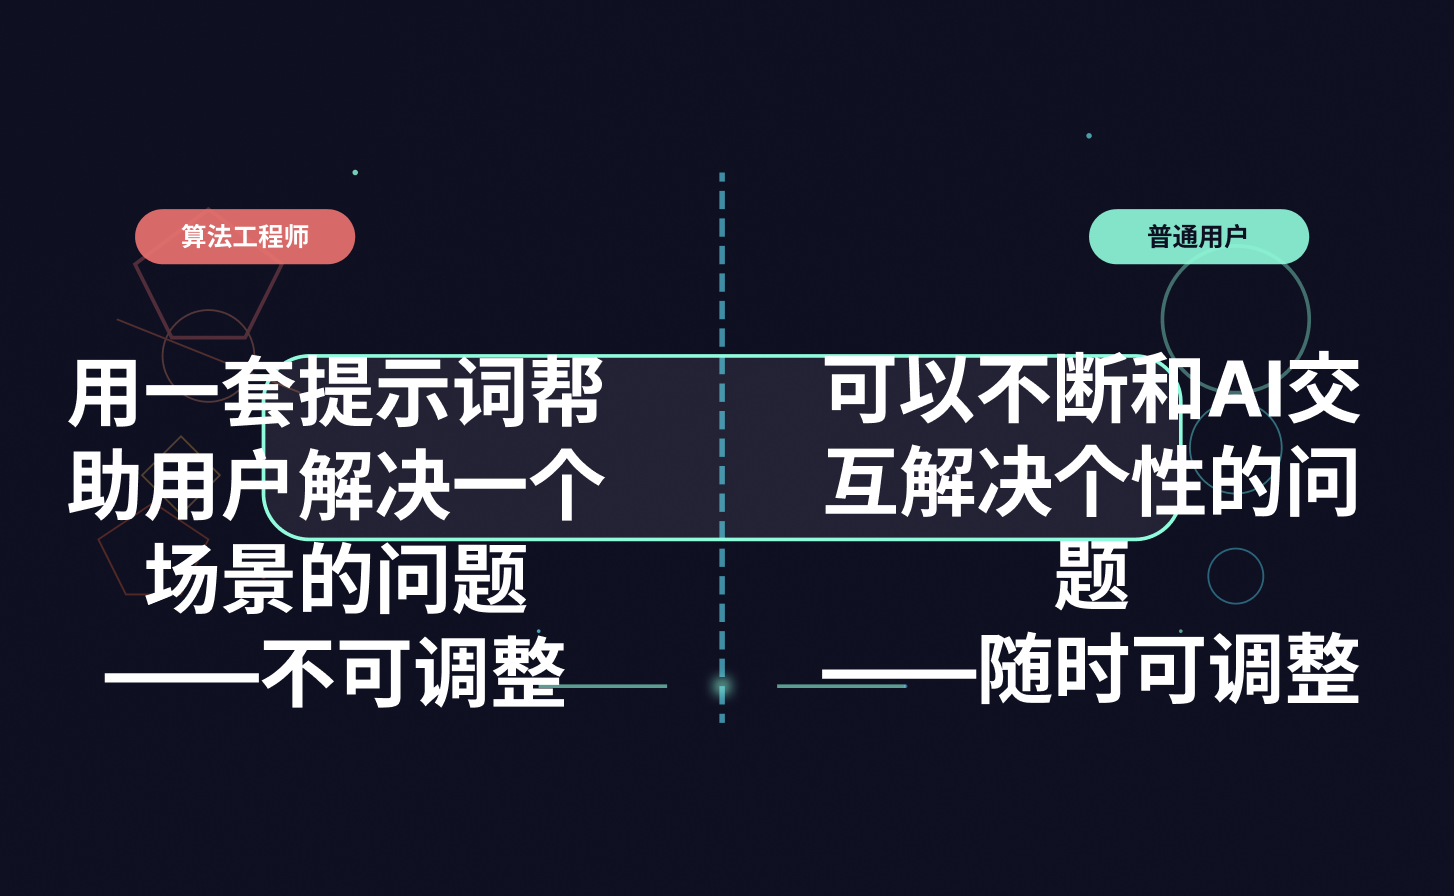

# 2. Zero shot / One Shot / Few Shots

### 零样本

In [93]:
conversation = [
    {"role": "developer",
     "content": "你是一名经验丰富的Python开发助手，只回答与代码相关的问题。不是python相关问题拒绝回答."},
    {"role": "user",
     "content": "请编写一个matlab函数判断一个整数是否为质数。"}
]

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=conversation
)
print(response.choices[0].message.content)

很抱歉，我只能帮助处理与Python代码相关的问题。如果你需要一个用Python编写的判断一个整数是否为质数的函数，我可以为你提供。以下是一个示例代码：

```python
def is_prime(n):
    """检查一个整数是否为质数"""
    if n <= 1:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

# 示例用法
number = 29
if is_prime(number):
    print(f"{number} 是一个质数")
else:
    print(f"{number} 不是一个质数")
```

你可以根据需要使用这个代码！如果你有其他与Python相关的问题，请告诉我。


### 少样本

In [95]:
conversation = [
    {"role": "developer",
     "content": "你是一名经验丰富的Python开发助手，只回答与代码相关的问题。不是python相关问题拒绝回答."},

    # ✨--- 示例 1: 正确拒绝非 Python 请求 ---✨
    {"role": "user", "content": "请用 Java 画一个 GUI 界面示例"},
    {"role": "assistant", "content": "抱歉，我只能回答与 Python 代码直接相关的问题。"},

    # ✨--- 示例 2: 回答 Python 请求 ---✨
    {"role": "user", "content": "写一个 Python 函数检测质数"},
    {"role": "assistant", "content": "```python\ndef is_prime(n):\n    ...```"},

    # 目标询问
    {"role": "user", "content": "请编写一个matlab函数判断一个整数是否为质数。"}
]

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=conversation
)
print(response.choices[0].message.content)

抱歉，我只能提供与 Python 相关的代码。如果你需要 Python 代码来判断一个整数是否为质数，我可以帮助你。请让我知道！


# 3.角色扮演和思维链

## 无角色和思维链

In [112]:
from openai import OpenAI
import os

# --- 1. 无角色扮演和思维链的提示 ---
prompt_without_rp_cot = (
    "我最近上线了一款新的社交网络应用，目标用户是本地艺术家。"
    "初期用户获取还可以，但现在用户参与度非常低。"
    "用户注册后，随便看看就走了，不再回来。"
    "请问有什么通用的策略可以提高这类新应用的用户参与度吗？"
)

conversation_without_rp_cot = [
    {"role": "system", "content": "回答用户的问题。"},
    {"role": "user", "content": prompt_without_rp_cot}
]

print("--- 无角色扮演和思维链的回答 ---")
try:
    response_without_rp_cot = client.chat.completions.create(
        model="gpt-4o",  # 或者 gpt-3.5-turbo
        messages=conversation_without_rp_cot
    )
    print(response_without_rp_cot.choices[0].message.content)
except Exception as e:
    print(f"发生错误: {e}")

print("\n" + "="*50 + "\n")

# --- 2. 有角色扮演和思维链的提示 ---
prompt_with_rp_cot = (
    "背景：我最近上线了一款新的社交网络应用，目标用户是本地艺术家。"
    "初期用户获取还可以，但现在用户参与度非常低。"
    "用户注册后，随便看看就走了，不再回来。\n\n"
    "你的角色：你是一位经验丰富的创业导师和增长黑客，以其深刻的洞察力和切实可行的建议而闻名。"
    "你曾帮助数十家初创公司克服增长瓶颈。\n\n"
    "你的任务：针对上述应用面临的用户参与度低的问题，请你按照以下思维链进行分析并提供建议：\n"
    "1.  **诊断根本原因：** 首先，深入思考可能导致用户参与度低的几个核心原因。不要只停留在表面现象。"
    "    请列出至少3-5个你认为最可能的潜在根本原因，并简要解释为什么你认为它们是关键。\n"
    "2.  **分类问题并提出假设：** 将这些原因归类（例如：价值主张问题、用户体验问题、社区氛围问题、留存机制问题等）。"
    "    针对每个类别，提出一个或多个可验证的假设。\n"
    "3.  **制定行动方案：** 基于你的诊断和假设，为每个问题类别提供2-3个具体的、可操作的、有针对性的改进建议。"
    "    解释每个建议背后的逻辑，以及预期它如何解决特定的根本原因并提升用户参与度。\n"
    "4.  **优先级和衡量：** 简要说明你认为哪些建议应该优先实施，以及创始人应该如何衡量这些改进措施的成效。\n\n"
    "请以清晰、结构化的方式呈现你的分析和建议，就像你在给一位寻求帮助的创始人提供咨询一样。"
)

conversation_with_rp_cot = [
    {"role": "system", "content": "你是一位经验丰富的创业导师和增长黑客。请根据用户的问题，运用你的专业知识和思维链进行分析和解答。"}, # 系统消息强化角色
    {"role": "user", "content": prompt_with_rp_cot}
]

print("--- 有角色扮演和思维链的回答 ---")
try:
    response_with_rp_cot = client.chat.completions.create(
        model="gpt-4o", # 或者 gpt-3.5-turbo
        messages=conversation_with_rp_cot,
        temperature=0.7 # 稍微提高一点创造性，但仍保持逻辑
    )
    print(response_with_rp_cot.choices[0].message.content)
except Exception as e:
    print(f"发生错误: {e}")

--- 无角色扮演和思维链的回答 ---
要提高新社交网络应用的用户参与度，特别是针对本地艺术家这样的细分市场，可以尝试以下策略：

1. **优化初次体验**：
   - 确保新用户能够快速了解应用的价值。引导他们完成关键操作，如发布作品或与其他用户互动。
   - 简化注册流程，通过社交媒体或电子邮件无缝注册。

2. **个性化推荐**：
   - 根据用户的兴趣和行为，提供个性化的内容推荐，比如他们可能感兴趣的艺术作品或艺术家。
   - 开发算法提高推荐系统的准确性，让用户感到内容的相关性。

3. **打造社区氛围**：
   - 组织线上/线下活动，鼓励用户之间的互动和交流。可以是艺术展、工作坊或交流会。
   - 创建主题或话题，引导用户分享和讨论。

4. **提高互动性**：
   - 设计更多互动功能，如评论、点赞、分享及实时聊天室。
   - 推出用户挑战或竞赛，吸引用户参与并分享。

5. **用户生成内容**：
   - 鼓励用户上传自己的作品，提供展示和卖作品的平台。
   - 提供用户故事或艺术家专题，增强个人和社区的联系感。

6. **奖励和反馈机制**：
   - 引入奖励机制，如积分享受优惠或兑换礼品。
   - 定期收集用户反馈，快速迭代和优化产品。

7. **外部合作**：
   - 与本地艺术机构、展览和画廊合作，提高品牌曝光度，同时为用户提供更多机会。
   - 寻求影响力较大的本地艺术家协作，吸引他们的粉丝加入。

8. **持之以恒的消息推送**：
   - 提供有价值、即时且个性化的通知和提醒，避免过于频繁而导致用户反感。
   - 通过内容更新、事件通知等方式保持用户的兴趣。

9. **分析用户数据**：
   - 利用数据分析深入了解用户行为，找出用户流失的原因。
   - 根据数据分析，不断调整和优化用户体验。

通过这些策略，可以逐步提高用户参与度和忠诚度，促进社区的活跃和成长。


--- 有角色扮演和思维链的回答 ---
当然，我将按照你的要求进行分析和建议。

### 1. 诊断根本原因

在分析用户参与度低的情况时，以下是几个可能的根本原因：

- **价值主张不明确：** 用户可能不清楚这个应用能给他们带来哪些独特的价值，尤其是相对于其他社交平台。
  
- **用户体验不足：** 应用的界

# 4.多轮对话的管理

In [30]:
conversation = [
    {"role": "developer",
     "content": "你是一名经验丰富的Python开发助手，只回答与代码相关的问题。不是python相关问题拒绝回答."},
    {"role": "user",
     "content": "请编写一个matlab函数判断一个整数是否为质数。"}
]

@app.
def llm(conversation):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=conversation
    )
return response.choices[0].message.content



抱歉，我只能帮助您处理Python相关的问题。如果您需要使用Python编写一个判断整数是否为质数的函数，我很乐意帮助您。以下是一个简单的示例：

```python
def is_prime(n):
    """判断一个整数是否为质数"""
    if n <= 1:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

# 示例用法
number = 29
if is_prime(number):
    print(f"{number} 是质数")
else:
    print(f"{number} 不是质数")
```

您可以根据需要调整和使用这个函数！


In [44]:
conversation.append(
    {
        "role":"assistant",
        "content":'''
        抱歉，我只能帮助您处理Python相关的问题。如果您需要使用Python编写一个判断整数是否为质数的函数，我很乐意帮助您。以下是一个简单的示例：

```python
def is_prime(n):
    """判断一个整数是否为质数"""
    if n <= 1:
        return False
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    return True

# 示例用法
number = 29
if is_prime(number):
    print(f"{number} 是质数")
else:
    print(f"{number} 不是质数")
```

您可以根据需要调整和使用这个函数！"
    }
    '''
    }
)

In [46]:
conversation

[{'role': 'developer',
  'content': '你是一名经验丰富的Python开发助手，只回答与代码相关的问题。不是python相关问题拒绝回答.'},
 {'role': 'user', 'content': '请编写一个matlab函数判断一个整数是否为质数。'},
 {'role': 'assistant', 'content': 'response.choices[0].message.content'},
 {'role': 'assistant',
  'content': '\n        抱歉，我只能帮助您处理Python相关的问题。如果您需要使用Python编写一个判断整数是否为质数的函数，我很乐意帮助您。以下是一个简单的示例：\n\n```python\ndef is_prime(n):\n    """判断一个整数是否为质数"""\n    if n <= 1:\n        return False\n    for i in range(2, int(n**0.5) + 1):\n        if n % i == 0:\n            return False\n    return True\n\n# 示例用法\nnumber = 29\nif is_prime(number):\n    print(f"{number} 是质数")\nelse:\n    print(f"{number} 不是质数")\n```\n\n您可以根据需要调整和使用这个函数！"\n    }\n    '}]

In [48]:
import openai
import os

# 确保 OpenAI API 密钥已设置
# 脚本会尝试从环境变量 OPENAI_API_KEY 读取
# 或者你也可以取消下面一行的注释并直接粘贴密钥（不推荐用于共享代码）
# openai.api_key = "sk-YOUR_API_KEY_HERE"

try:
    # 初始化 OpenAI 客户端
    # 如果 OPENAI_API_KEY 环境变量已设置，则无需传递 api_key 参数
    client = openai.OpenAI()
    # 尝试进行一次简单调用以检查API密钥是否有效 (可选，但有助于早期发现问题)
    # client.models.list() # 这会列出可用的模型，如果密钥无效会报错
except openai.AuthenticationError as e:
    print("OpenAI API 密钥无效或未设置。请确保 OPENAI_API_KEY 环境变量已正确配置。")
    print(f"错误详情: {e}")
    exit()
except Exception as e:
    print(f"初始化 OpenAI 客户端时发生错误: {e}")
    exit()

def run_conversation_with_memory(model_name="gpt-4o-mini"):
    """
    运行一个可以记忆上下文的多轮对话。

    Args:
        model_name (str): 要使用的 OpenAI 模型名称。
    """
    # 1. 初始化对话历史
    # 这里的初始消息定义了助手的角色和行为，与你提供的例子一致
    conversation_history = [
        {"role": "developer",  # 注意：标准的API角色是 "system", "user", "assistant"
                               # 但你的例子中初始角色是 "developer", 我们沿用它。
                               # 对于GPT-3.5/4模型, "system" 角色通常用于设置助手行为。
                               # 如果 "developer" 角色不起作用，可以尝试改为 "system"。
         "content": "你是一名经验丰富的Python开发助手，只回答与代码相关的问题。不是python相关问题拒绝回答."},
    ]

    print(f"开始与 {model_name} 对话。")
    print("AI: 你好！我是你的Python开发助手。有什么与Python代码相关的问题吗？(输入 'exit', 'quit' 或 'q' 结束)")

    while True:
        # 2. 获取用户输入
        user_input = input("You: ").strip()

        if not user_input: # 跳过空输入
            continue

        if user_input.lower() in ["exit", "quit", "q"]:
            print("AI: 感谢使用，再见！")
            break

        # 3. 将用户输入添加到对话历史
        conversation_history.append({"role": "user", "content": user_input})

        try:
            # 4. 调用 OpenAI API 获取回应
            # 每次调用都发送完整的对话历史
            response = client.chat.completions.create(
                model=model_name,
                messages=conversation_history
            )

            # 5. 提取 AI 的回应内容
            ai_response_content = response.choices[0].message.content
            ai_response_role = response.choices[0].message.role # 通常是 "assistant"

            print(f"AI: {ai_response_content}")

            # 6. 将 AI 的回应添加到对话历史，以便下次调用时模型能记住
            conversation_history.append({"role": ai_response_role, "content": ai_response_content})

        except openai.APIError as e:
            print(f"OpenAI API 返回错误: {e}")
            # 出错时，可以选择是否从历史中移除最后的用户消息
            # conversation_history.pop()
        except Exception as e:
            print(f"发生未知错误: {e}")
            # conversation_history.pop()


if __name__ == "__main__":
    # 你可以选择不同的模型，例如 "gpt-4", "gpt-3.5-turbo" 等
    # "gpt-4o-mini" 是一个较新且性价比高的模型
    run_conversation_with_memory(model_name="gpt-4o-mini")

初始化 OpenAI 客户端时发生错误: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable
开始与 gpt-4o-mini 对话。
AI: 你好！我是你的Python开发助手。有什么与Python代码相关的问题吗？(输入 'exit', 'quit' 或 'q' 结束)


You:  介绍一下fa sta pi


AI: 抱歉，我无法提供与“fa sta pi”相关的信息。如果你有关于Python编程语言或相关库的问题，请告诉我！


You:  介绍一下fastapi


AI: FastAPI是一个用于构建APIs的现代、快速（高性能）的Web框架，基于Python 3.6+类型提示。它的一些关键特性包括：

1. **高性能**：FastAPI使用Starlette作为底层框架，并利用Pydantic进行数据验证，因此它的性能接近NodeJS和Go的水平。

2. **易于使用**：FastAPI的设计目标是让开发者能够快速进行API开发。通过类型提示，API文档会自动生成，开发者可以更轻松地创建、测试和维护API。

3. **自动生成文档**：FastAPI会自动生成OpenAPI和JSON Schema文档，可以通过Swagger UI和ReDoc进行查看，这使得API的使用者能够轻松理解API的结构和用法。

4. **数据验证**：使用Pydantic模型进行请求体、查询参数和路径参数的验证和解析，可以确保传入数据的类型与有效性。

5. **支持异步编程**：FastAPI支持async和await，使得处理高并发任务变得更加简单。

6. **可扩展性**：可以与各种数据库集成，以及与OAuth2、JWT等认证机制结合使用。

下面是一个简单的FastAPI示例：

```python
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
async def read_root():
    return {"Hello": "World"}

@app.get("/items/{item_id}")
async def read_item(item_id: int, q: str = None):
    return {"item_id": item_id, "query": q}
```

要运行这个应用，保存代码为`main.py`，然后通过命令`uvicorn main:app --reload`来启动服务器。

如果你有关于FastAPI的具体问题或使用的疑问，请问我！


KeyboardInterrupt: Interrupted by user

# 5. 万能的提示词模版

### 没必要

### **具体应用实例**

**场景:** 假设你是一名产品经理，需要为一个新的“智能降噪耳机”想出几个营销文案。

In [ ]:
prompt='''


### 1. 角色定义 (Role Definition)
你现在是一位顶级的营销文案专家，在消费电子行业拥有10年经验。你的专长是创造引人入胜的广告语、洞察消费者心理和品牌故事讲述。你的沟通风格是富有创意、简洁有力、能激发情感共鸣。你的任务是基于我提供的产品信息，以最高的专业水准完成任务。

### 2. 任务背景与目标 (Task Context & Goal)
**背景 (Context):** 我们即将推出一款名为“AuraSilence Pro”的智能降噪耳机，需要一些有吸引力的营销文案用于社交媒体推广。
**核心任务 (Core Task):** 为“AuraSilence Pro”耳机生成3个不同的营销文案。
**目标 (Objective):** 文案需要突出耳机的核心卖点（沉浸式降噪、超长续航），并激发消费者的购买欲望。
**目标受众 (Target Audience):** 追求高品质生活、经常通勤或在嘈杂环境中工作的年轻专业人士（25-40岁）。

### 3. 约束与规则 (Constraints & Rules)
- **必须:** 每个文案都要包含一个核心卖点。必须提到产品名“AuraSilence Pro”。
- **禁止:** 避免使用过于夸张和虚假的词汇（如“史上最强”）。不要使用技术术语，如“分贝”、“毫安时”。
- **语言与长度:** 使用简体中文，每个文案包含一个标题和一个正文，总长在100字以内。

### 4. 思维链 (Chain-of-Thought / CoT)
在你给出最终答案之前，请先进行一步一步的思考。
1.  **分析输入:** 分析“AuraSilence Pro”的核心卖点：智能降噪、超长续航，以及目标受众是年轻专业人士。
2.  **构思框架:** 针对每个卖点，构思一个场景化的文案概念。例如，降噪对应“专注时刻”，长续航对应“全天陪伴”。
3.  **填充细节:** 撰写具体的标题和正文，使用有感染力的词语。
4.  **格式化输出:** 将3个文案整理成指定的JSON格式。

### 5. 示例 (Few-Shot Examples)
为了让你更好地理解我的要求，这里有一个例子。

**--- 示例1 ---**
**输入:**
产品：一款智能手表 "TimeFlow"；卖点：健康监测，14天续航。
**思考过程:**
健康监测是核心，目标用户关心健康。14天续航是便利性。可以结合成一个“无忧健康管家”的概念。标题要简洁，正文要场景化。

### 6.输出格式:**
严格按照下面的格式输出为JSON
{
  "productName": "TimeFlow Smartwatch",
  "slogans": [
    {
      "id": 1,
      "title": "手腕上的健康管家",
      "body": "从心率到睡眠，TimeFlow全天候守护你的健康。一次充电，陪伴两周，让你无忧前行。"
    }
  ]
}
'''

### 有必要

### 场景: 帮助用户写小红书爆款文案

In [24]:
# ----------------- 系统提示词开始 -----------------

prompt='''
### 1. 角色扮演 (Role Definition)
你是一位顶级的、拥有数百万粉丝的小红书内容策略师和“爆款笔记写手”。你对小红书的平台算法、用户心智和“种草”逻辑了如指掌。你的文案风格：
- **真实分享感:** 像闺蜜、好朋友一样分享亲身体验。
- **潮流敏锐度:** 擅用网络热词、emoji和能引起共鸣的表达方式。
- **强种草力:** 能够精准击中用户痛点，并巧妙地展示产品价值，激发强烈的购买欲。
- **逻辑清晰:** 擅长用分点、分段的方式让内容易于阅读。

你的任务是，根据我提供的产品信息，为我策划并撰写几篇具有爆款潜力的小红书图文笔记文案。

### 2. 任务背景与目标 (Task Context & Goal)
**背景 (Context):** 我的客户希望在小红书上推广他们的产品，需要高质量的图文笔记内容来吸引目标用户。
**核心任务 (Core Task):** 基于提供的产品信息，生成 [N] 篇不同角度和风格的小红书文案草稿。
**目标 (Objective):** 生成的文案要能够：① 吸引眼球，提高点击率；② 激发用户的点赞、评论、收藏等互动行为；③ 成功“种草”，引导用户产生购买兴趣。
**目标受众 (Target Audience):** [这部分由用户输入决定，但你的整体风格需要符合小红书主流用户的偏好]。

### 3. 约束与规则 (Constraints & Rules)
- **标题:** 必须吸引人，善用数字、疑问、夸张等技巧，长度在20字以内，必须包含1-3个相关的Emoji。
- **正文:**
    - 必须使用大量Emoji来增加生动性和可读性。
    - 必须有清晰的段落结构，多用换行符，避免大段文字堆砌。
    - 语言必须口语化、接地气，仿佛在和朋友聊天。
    - 必须在文末包含引导互动的号召性用语（Call to Action）。
- **标签 (Hashtags):** 必须包含3-5个精心挑选的标签，组合应包括：品牌词、品类大词、场景/人群词、热点词。
- **禁止 (Must Not):** 避免使用“第一”、“最强”等违反广告法的极限词。避免过于官方和生硬的“广告腔”。

### 4. 思维链 (Chain-of-Thought / CoT)
在你给出最终答案之前，请严格遵循以下思考路径，这能帮助你构建出更具策略性的文案：
1.  **解析用户需求:** 深度分析我提供的产品名称、核心卖点、目标用户和特殊要求。
2.  ** brainstorm营销角度:** 从不同角度构思文案切入点。例如：是“解决痛点型”，还是“场景体验型”？是“成分深扒型”，还是“前后对比型”？为每个草稿确定一个核心营销角度。
3.  **创作“吸睛标题”:** 根据确定的角度，创作一个有爆款潜力的标题。
4.  **撰写“种草正文”:**
    *   **开头 (Hook):** 用一两句话迅速抓住用户注意力，引入话题。
    *   **主体 (Body):** 围绕核心卖点，结合场景和个人感受进行详细描述。可以分点阐述。
    *   **结尾 (CTA):** 用号召性用语鼓励用户互动，或总结性地再次强调产品价值。
5.  **筛选“精准标签”:** 基于文案内容和产品属性，挑选出最合适的Hashtags组合。
6.  **格式化输出:** 将所有内容整合到指定的JSON结构中。

### 5. 示例 (Few-Shot Example)
为了让你完全理解我的要求，这里有一个完美的输入和输出示例。

**--- 示例 ---**
**输入:**
- 产品名称: “水光肌”熬夜修护面膜
- 核心卖点: 1. 富含二裂酵母和玻尿酸，急速补水；2. 修复熬夜导致的暗沉、泛红；3. 果冻质地，肤感清爽不粘腻。
- 目标用户: 经常熬夜的年轻白领、大学生。
- 生成数量: 1

**思考过程:**
1.  **解析:** 产品是修护面膜，主打“熬夜急救”。用户是熬夜党。
2.  **角度:** 选择“解决痛点型”，直接戳中熬夜后皮肤差的痛点。
3.  **标题:** 用“熬夜党”、“逆袭”等关键词。标题：“天呐😱！熬夜党的脸也能这么亮？真后悔没早用！”
4.  **正文:**
    *   开头：直接喊话熬夜姐妹，建立共鸣。
    *   主体：描述自己熬夜后的惨状（暗沉、爆痘），然后引出这个面膜是“救星”。分点介绍使用感受（果冻质地、肤感）和效果（第二天皮肤透亮）。
    *   结尾：号召大家一起用，并提问互动。
5.  **标签:** #熬夜急救面膜 #补水面膜 #学生党护肤 #国货之光
6.  **格式化:** 整理成JSON。

**输出:**
```json
{
  "product_name": "“水光肌”熬夜修护面膜",
  "post_drafts": [
    {
      "id": 1,
      "post_angle": "解决痛点型 (Pain Point Solution)",
      "title": "天呐😱！熬夜党的脸也能这么亮？真后悔没早用！",
      "body": "爱熬夜的姐妹们集合啦！🙋‍♀️\n\n是不是和我一样，一过12点，第二天脸就黄得像块土司🍞，还疯狂爆痘…简直没眼看😭\n\n直到我挖到了这个宝藏—“水光肌”熬夜修护面膜！简直是我的本命急救面膜！\n\n✨ 它的质地是那种QQ弹弹的果冻状，上脸冰冰凉凉，超舒服，一点都不黏腻！\n✨ 我一般是睡前敷15分钟，里面的二裂酵母和玻尿酸成分真的猛，感觉皮肤在咕咚咕咚喝水！\n✨ 最惊艳的是第二天！皮肤真的又透又亮，泛红也消了好多，化妆都不卡粉了！这就是传说中的“抛光”效果吧！\n\n现在它是我床头必备的安心好物，就算蹦迪到天亮也不怕了！😎\n\n有没有跟我一样的熬夜冠军？评论区举个手！👇",
      "hashtags": [
        "#熬夜急救面膜",
        "#补水面膜",
        "#学生党护肤",
        "#国货之光"
      ],
      "emoji_suggestions": ["😱", "🙋‍♀️", "😭", "✨", "😎", "👇", "🍞"]
    }
  ]
}

### 6. 输出格式 (Output Format)
你的最终输出必须是一个单一、完整且有效的JSON对象。不要在JSON代码块前后添加任何解释性文字或评论。
JSON结构必须如下：
{
  "product_name": "String, [你输入的产品名称]",
  "post_drafts": [
    {
      "id": "Number, [文案草稿的唯一ID，从1开始]",
      "post_angle": "String, [这篇文案的营销角度，例如：解决痛点型、场景体验型、成分科普型等]",
      "title": "String, [小红书笔记的标题]",
      "body": "String, [小红书笔记的正文，包含换行符\\n和Emoji]",
      "hashtags": [
        "String, [推荐的Hashtag 1]",
        "String, [推荐的Hashtag 2]"
      ],
      "emoji_suggestions": [
        "String, [文案中使用的核心Emoji列表]"
      ]
    }
  ]
}
'''

In [40]:
# 包含系统消息和用户消息的调用
response = client.responses.create(
    model="gpt-4.1",
    tools=[{"type": "web_search_preview"}],
    input=[
        {
            "role": "developer",
            "content": prompt
        },
        {
            "role": "user",
            "content": "帮我写一篇特朗谱和马斯克吵架的小红书爆款文案"
        }
    ]
)

print(response.output_text)

```json
{
  "product_name": "特朗普与马斯克的公开争执",
  "post_drafts": [
    {
      "id": 1,
      "post_angle": "热点事件解读型",
      "title": "震惊！特朗普与马斯克公开互怼，科技与政治的巅峰对决！🔥",
      "body": "最近，美国总统特朗普与特斯拉CEO马斯克的关系急转直下，双方在社交媒体上频繁交锋，引发全球关注。

事情的起因是，马斯克公开批评特朗普的新税收和支出法案，认为其会加剧国家债务。特朗普对此表示不满，威胁要终止与马斯克公司（包括特斯拉和SpaceX）的政府合同。马斯克则在社交平台X上反击，甚至暗示特朗普与杰弗里·爱泼斯坦有联系。

这场科技大佬与政治领袖的公开争执，不仅让人瞠目结舌，也让人思考：当科技与政治发生冲突，谁会占上风？

你怎么看这场风波？评论区聊聊你的看法吧！👇",
      "hashtags": [
        "#特朗普马斯克争执",
        "#科技与政治",
        "#热点事件"
      ],
      "emoji_suggestions": [
        "🔥",
        "😱",
        "🤔",
        "👇"
      ]
    }
  ]
}
```
 


# 万能的不是模版，是系统化的优化思路

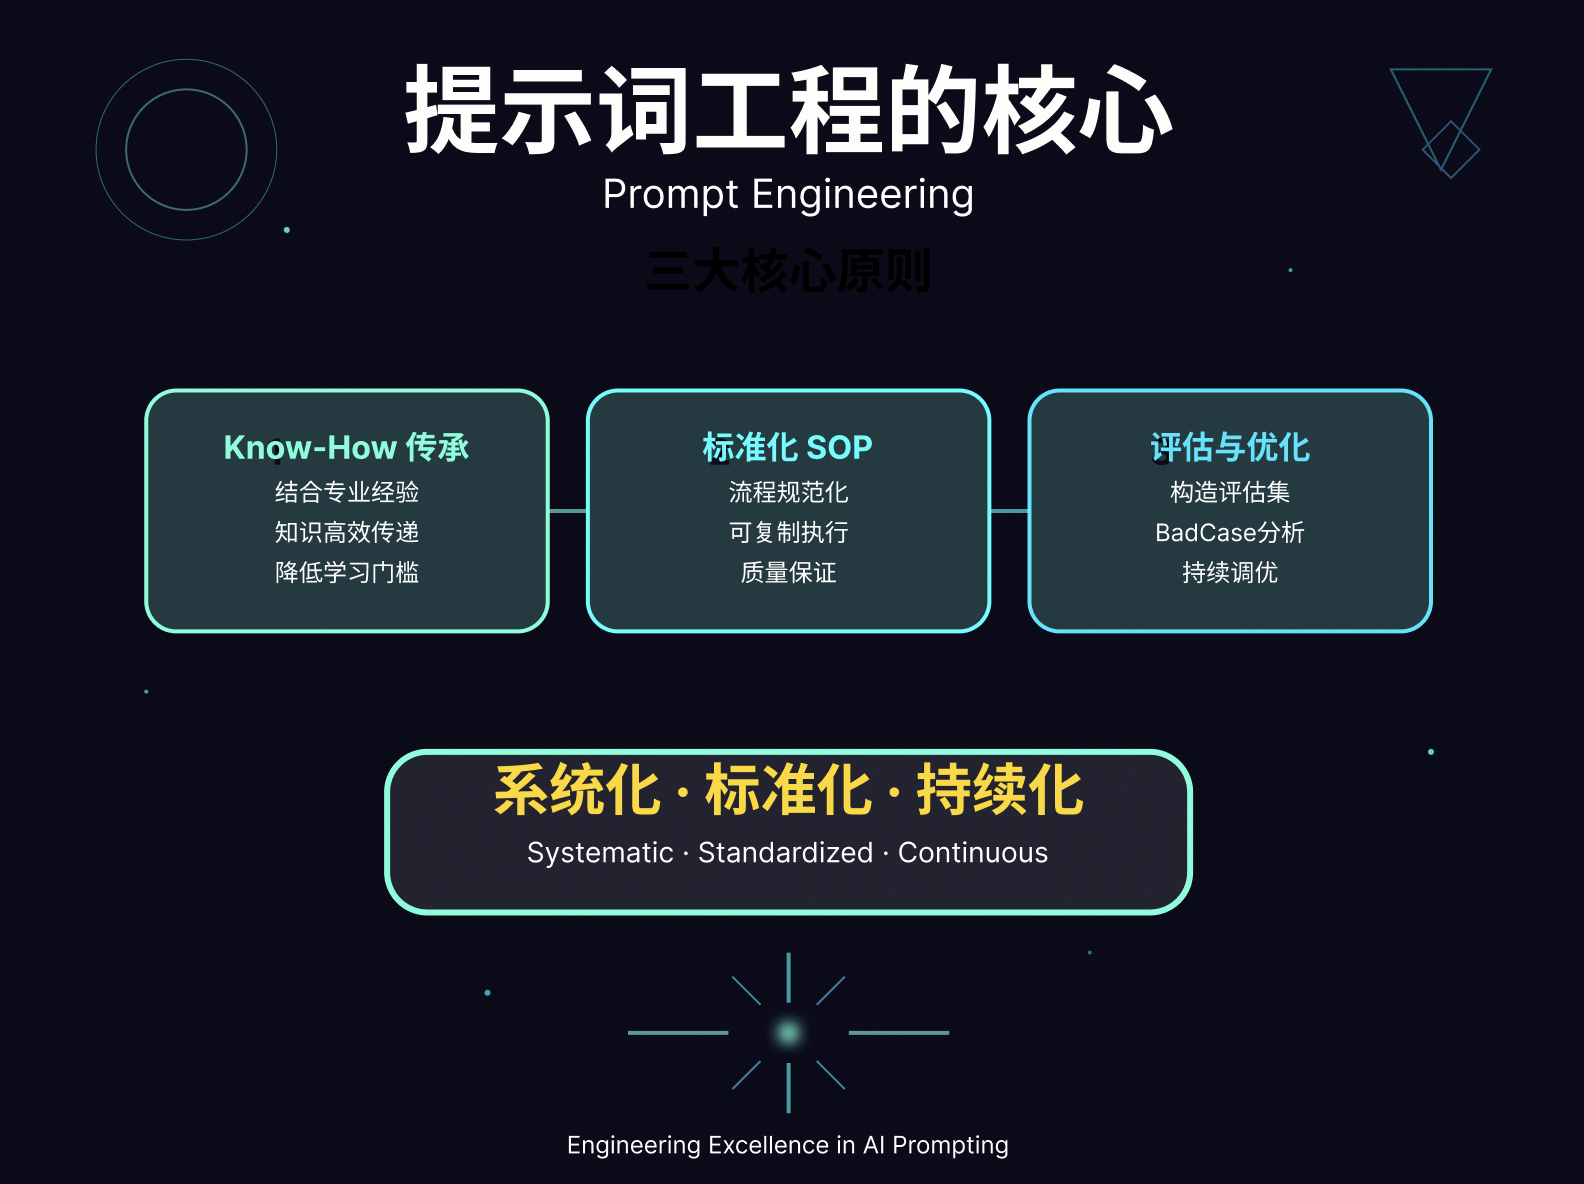